In [7]:
import pandas as pd
import numpy as np
import random

NUM_WARDS = 198
YEARS = 3 # 36 Months
START_YEAR = 2021
MONTHS_PER_YEAR = 12
TOTAL_MONTHS = YEARS * MONTHS_PER_YEAR


def get_bengaluru_rainfall(month):
    if month in [6, 7, 8, 9]:
        return np.random.normal(150, 40) # High rain (mm)
    elif month in [5, 10, 11]:
        return np.random.normal(80, 25)  # Moderate rain
    else:
        return np.random.normal(10, 5)   # Dry season

def get_bengaluru_temp(month):
    if month in [3, 4, 5]:     # Summer
        return np.random.normal(34, 2)
    elif month in [12, 1, 2]:  # Winter
        return np.random.normal(20, 2)
    else:                      # Moderate
        return np.random.normal(27, 2)

def determine_risk(cases):
    if cases < 20:
        return 'Low'
    elif 20 <= cases < 60:
        return 'Medium'
    else:
        return 'High'


data = []


for ward_id in range(1, NUM_WARDS + 1):
    ward_hygiene_score = np.random.uniform(0.5, 1.5)

    prev_month_rain = 0

    for year_offset in range(YEARS):
        year = START_YEAR + year_offset
        for month in range(1, 13):

            rain = max(0, get_bengaluru_rainfall(month))
            temp = get_bengaluru_temp(month)

            base_garbage = np.random.randint(5, 50) * ward_hygiene_score
            base_waterlogging = (rain * 0.1) + (np.random.randint(0, 10) * ward_hygiene_score)

            garbage_complaints = int(base_garbage)
            waterlogging_complaints = int(base_waterlogging)

            rain_impact = prev_month_rain * 0.15
            civic_impact = (garbage_complaints * 0.5) + (waterlogging_complaints * 0.8)

            temp_factor = 1.0
            if 24 <= temp <= 30:
                temp_factor = 1.2

            estimated_cases = (rain_impact + civic_impact) * temp_factor
            actual_dengue_cases = int(max(0, np.random.normal(estimated_cases, 5)))

            risk_level = determine_risk(actual_dengue_cases)

            prev_month_rain = rain

            data.append({
                'Ward_ID': ward_id,
                'Year': year,
                'Month': month,
                'Rainfall_mm': round(rain, 1),
                'Avg_Temp_C': round(temp, 1),
                'Garbage_Complaints': garbage_complaints,
                'Waterlogging_Complaints': waterlogging_complaints,
                'Dengue_Cases': actual_dengue_cases,
                'Risk_Level': risk_level
            })

df = pd.DataFrame(data)

df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

csv_filename = 'bengaluru_wards_synthetic.csv'
df.to_csv(csv_filename, index=False)

print(f"Dataset saved as '{csv_filename}'")
print(f"Total Records: {len(df)}")
print(df.head())

Success! Dataset saved as 'bengaluru_wards_synthetic.csv'
Total Records: 7128
   Ward_ID  Year  Month  Rainfall_mm  Avg_Temp_C  Garbage_Complaints  \
0        1  2021      1          0.1        17.5                  48   
1        1  2021      2         13.0        19.3                   6   
2        1  2021      3         10.3        33.2                  14   
3        1  2021      4          9.2        36.5                  32   
4        1  2021      5         47.4        37.6                  34   

   Waterlogging_Complaints  Dengue_Cases Risk_Level       Date  
0                        4            19        Low 2021-01-01  
1                        8             8        Low 2021-02-01  
2                        5             5        Low 2021-03-01  
3                        5            21     Medium 2021-04-01  
4                       13            27     Medium 2021-05-01  


Dataset loaded successfully.
Columns found: ['Ward_ID', 'Year', 'Month', 'Rainfall_mm', 'Avg_Temp_C', 'Garbage_Complaints', 'Waterlogging_Complaints', 'Dengue_Cases', 'Risk_Level', 'Date']


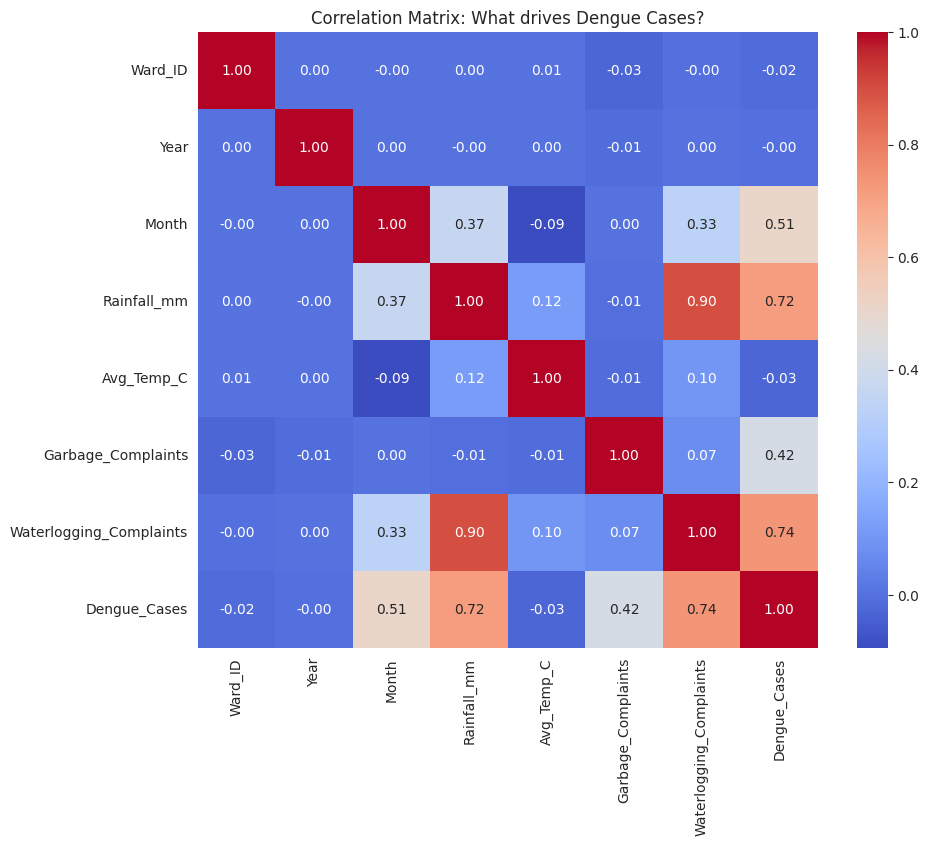

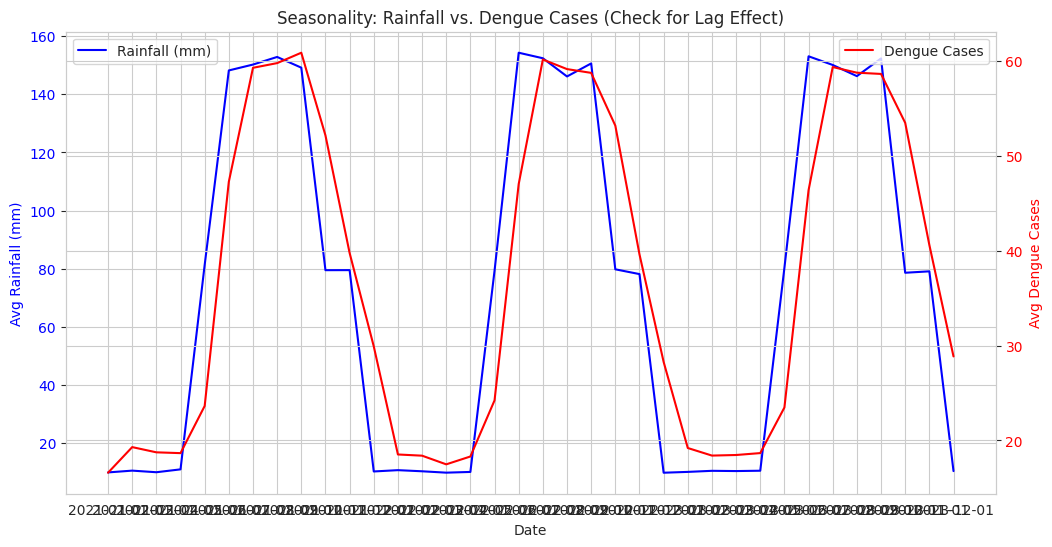

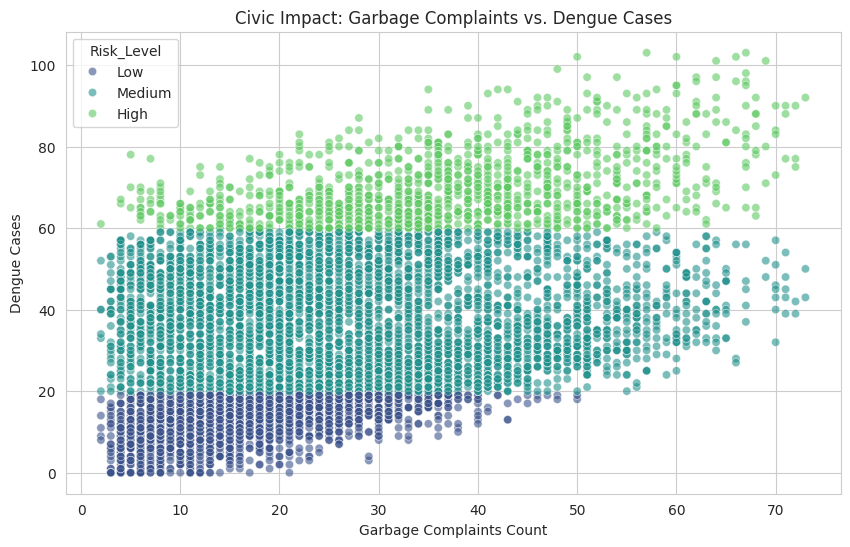

/tmp/ipython-input-1079930519.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df, order=['Low', 'Medium', 'High'], palette='pastel')


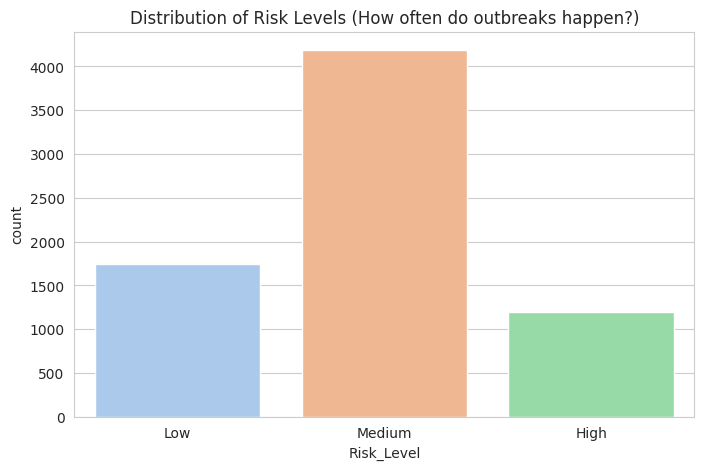

/tmp/ipython-input-1079930519.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ward_risk.index, y=ward_risk.values, palette='Reds_r')


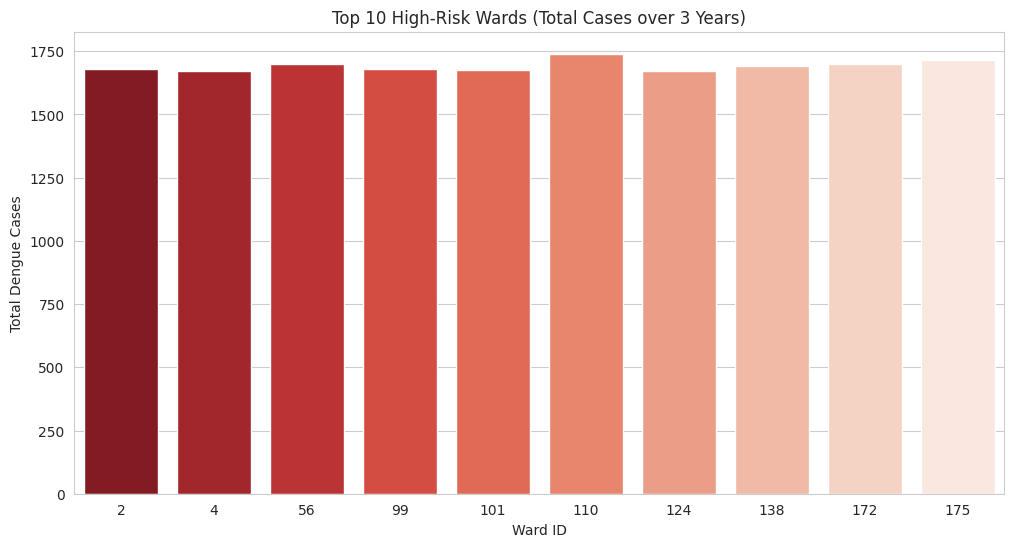

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('bengaluru_wards_dataset.csv')
    print("Dataset loaded successfully.")
    print(f"Columns found: {list(df.columns)}")
except FileNotFoundError:
    print("Error: 'bengaluru_wards_dataset.csv' not found. Please run the generation script first.")
    exit()

sns.set_style("whitegrid")

if 'Date' not in df.columns:
    df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: What drives Dengue Cases?")
plt.show()

monthly_avg = df.groupby('Date')[['Rainfall_mm', 'Dengue_Cases']].mean()

plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(data=monthly_avg, x='Date', y='Rainfall_mm', color='blue', label='Rainfall (mm)')
ax1.set_ylabel('Avg Rainfall (mm)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='Date', y='Dengue_Cases', color='red', label='Dengue Cases', ax=ax2)
ax2.set_ylabel('Avg Dengue Cases', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Seasonality: Rainfall vs. Dengue Cases (Check for Lag Effect)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Garbage_Complaints',
    y='Dengue_Cases',
    hue='Risk_Level',
    hue_order=['Low', 'Medium', 'High'],
    palette='viridis',
    alpha=0.6
)
plt.title("Civic Impact: Garbage Complaints vs. Dengue Cases")
plt.xlabel("Garbage Complaints Count")
plt.ylabel("Dengue Cases")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='Risk_Level', data=df, order=['Low', 'Medium', 'High'], palette='pastel')
plt.title("Distribution of Risk Levels (How often do outbreaks happen?)")
plt.show()

ward_risk = df.groupby('Ward_ID')['Dengue_Cases'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=ward_risk.index, y=ward_risk.values, palette='Reds_r')
plt.title("Top 10 High-Risk Wards (Total Cases over 3 Years)")
plt.xlabel("Ward ID")
plt.ylabel("Total Dengue Cases")
plt.show()



Training on 5385 records, Testing on 1347 records.
------------------------------
Results:
RMSE : 5.44
R2 Score : 0.93
------------------------------


<Figure size 1000x600 with 0 Axes>

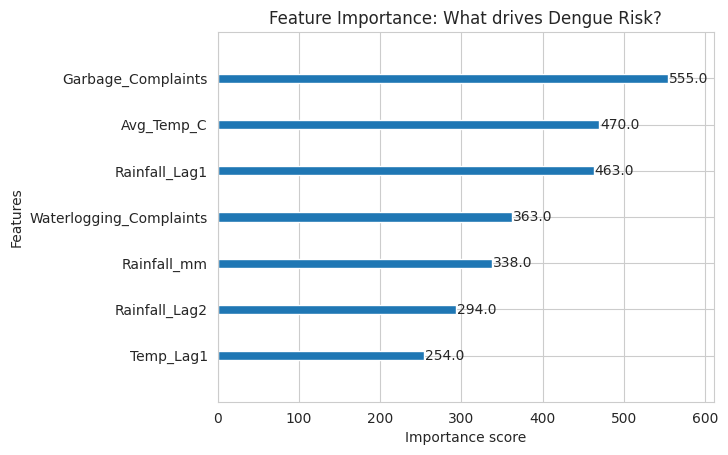

['dengue_prediction_model.pkl']

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('bengaluru_wards_synthetic.csv')

df['Rainfall_Lag1'] = df.groupby('Ward_ID')['Rainfall_mm'].shift(1)
df['Rainfall_Lag2'] = df.groupby('Ward_ID')['Rainfall_mm'].shift(2)
df['Temp_Lag1'] = df.groupby('Ward_ID')['Avg_Temp_C'].shift(1)

df = df.dropna()

features = [
    'Rainfall_mm', 'Avg_Temp_C',
    'Garbage_Complaints', 'Waterlogging_Complaints',
    'Rainfall_Lag1', 'Rainfall_Lag2', 'Temp_Lag1'
]
target = 'Dengue_Cases'

X = df[features]
y = df[target]

train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training on {len(X_train)} records, Testing on {len(X_test)} records.")

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("-" * 30)
print(f"Results:")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.2f}")
print("-" * 30)

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10)
plt.title('Feature Importance: What drives Dengue Risk?')
plt.show()

joblib.dump(model, 'dengue_prediction_model.pkl')
